In [17]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from scipy.stats import pearsonr, spearmanr

pre = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/timing_cancer_events/chr_loss_timing_PeterVanLoo/Pre-WGD loss proportions.csv", index_col=0)
post = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/timing_cancer_events/chr_loss_timing_PeterVanLoo/Post-WGD loss proportions.csv", index_col=0)
regression_folder = "/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/TCGA_Deconvolutions_CNV_IS/Arm/Outputs"

print(pre.shape)
print(pre.columns)
print(post.shape)
print(post.columns)

(70, 44)
Index(['10p', '10q', '11p', '11q', '12p', '12q', '13p', '13q', '14p', '14q',
       '15p', '15q', '16p', '16q', '17p', '17q', '18p', '18q', '19p', '19q',
       '1p', '1q', '20p', '20q', '21p', '21q', '22p', '22q', '2p', '2q', '3p',
       '3q', '4p', '4q', '5p', '5q', '6p', '6q', '7p', '7q', '8p', '8q', '9p',
       '9q'],
      dtype='object')
(70, 44)
Index(['10p', '10q', '11p', '11q', '12p', '12q', '13p', '13q', '14p', '14q',
       '15p', '15q', '16p', '16q', '17p', '17q', '18p', '18q', '19p', '19q',
       '1p', '1q', '20p', '20q', '21p', '21q', '22p', '22q', '2p', '2q', '3p',
       '3q', '4p', '4q', '5p', '5q', '6p', '6q', '7p', '7q', '8p', '8q', '9p',
       '9q'],
      dtype='object')


In [22]:
# Timing = Post-WGD loss − Pre-WGD loss
timing = post - pre

# Check a few rows
print(timing.head())

                                   10p       10q       11p       11q  \
Acute myeloid leukemia        0.000000  0.000000  0.000000  0.000000   
Adrenal gland cancer          0.400000  0.400000 -0.400000 -0.400000   
Bladder urothelial carcinoma  0.208955  0.007463  0.111940  0.126866   
Bone benign tumor             0.000000  0.000000  0.000000  0.000000   
Breast carcinoma              0.190909  0.106061  0.128283 -0.053535   

                                   12p       12q       13p       13q  \
Acute myeloid leukemia        0.000000  0.000000  0.000000  0.000000   
Adrenal gland cancer          0.200000  0.400000 -0.400000 -0.400000   
Bladder urothelial carcinoma  0.208955  0.365672  0.298507  0.104478   
Bone benign tumor             0.000000  0.000000  0.000000  0.000000   
Breast carcinoma              0.069697  0.083838 -0.044444 -0.102020   

                                   14p       14q  ...        5p        5q  \
Acute myeloid leukemia        0.000000  0.000000  ...  0.

In [ ]:
# load z score for loss only
zval_dict = {}
all_files = glob(os.path.join(regression_folder, "*_ArmCNV_binary0.2_regression.csv"))

for f in all_files:
    df = pd.read_csv(f)
    tumor_code = os.path.basename(f).split("_")[0].split(".")[0]  # handles BRCA.pos, etc.
    if "Z_val" in df.columns and "Event" in df.columns and "Arm" in df.columns:
        df_loss = df[df["Event"] == "Loss"]
        df_loss = df_loss.set_index("Arm")
        zval_dict[tumor_code] = df_loss["Z_val"]

print("Loaded tumors:", list(zval_dict.keys()))

Loaded tumors: ['BRCA', 'UCS', 'DLBC', 'CESC', 'CHOL', 'LGG', 'HNSC', 'BLCA', 'READ', 'SARC', 'THYM', 'KICH', 'THCA', 'COAD', 'LUAD', 'OV', 'LUSC', 'MESO', 'KIRP', 'STES', 'ESCA', 'UCEC', 'SKCM', 'COADREAD', 'STAD', 'TGCT', 'PCPG', 'LAML', 'PRAD', 'GBM', 'KIRC', 'KIPAN']


In [24]:
results = []

for tumor in zval_dict:
    if tumor in timing.columns:
        timing_vals = timing[tumor].dropna()
        zvals = zval_dict[tumor]
        common_arms = timing_vals.index.intersection(zvals.index)

        if len(common_arms) >= 3:
            r, p = spearmanr(timing_vals[common_arms], zvals[common_arms])
            results.append({
                "Tumor": tumor,
                "Spearman_r": r,
                "P_val": p,
                "n_arms": len(common_arms)
            })

result_df = pd.DataFrame(results)

In [25]:
if not result_df.empty:
    result_df = result_df.sort_values("Spearman_r")
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=result_df, y="Tumor", x="Spearman_r", color="grey")
    plt.axvline(0, color='red', linestyle='--')
    plt.xlabel("Spearman r (CNV timing vs immune depletion)")
    plt.title("Association between CNV Timing and Immune Depletion")
    plt.tight_layout()
    plt.show()
else:
    print("No valid tumor types found with matching timing and Z_val arms.")

No valid tumor types found with matching timing and Z_val arms.


In [27]:
# Check a sample regression file
import pandas as pd
import os
from glob import glob

regression_folder = "/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/TCGA_Deconvolutions_CNV_IS/Arm/Outputs"
sample_file = glob(os.path.join(regression_folder, "*_ArmCNV_binary0.2_regression.csv"))[0]
print("Sample file:", sample_file)

df = pd.read_csv(sample_file)
print("Columns:", df.columns.tolist())
print(df.head())

Sample file: /Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/TCGA_Deconvolutions_CNV_IS/Arm/Outputs/BRCA_is0.3_ArmCNV_binary0.2_regression.csv
Columns: ['Coefficients', 'Std_Error', 'Z_val', 'P_val', 'Arm', 'Event', 'Chromosome', 'ChrArm']
   Coefficients  Std_Error     Z_val     P_val Arm Event Chromosome ChrArm
0      0.414924   0.203677  2.037171  0.041633  1p  Gain       Chr1  Chr1p
1     -0.376422   0.216718 -1.736922  0.082401  1p  Loss       Chr1  Chr1p
2     -0.020590   0.166471 -0.123687  0.901563  1q  Gain       Chr1  Chr1q
3     -0.113216   0.426651 -0.265361  0.790731  1q  Loss       Chr1  Chr1q
4      0.692699   0.272648  2.540636  0.011065  2p  Gain       Chr2  Chr2p


In [29]:
print(result_df.columns)

RangeIndex(start=0, stop=0, step=1)


In [30]:
print("pre.columns:", list(pre.columns))
print("post.columns:", list(post.columns))
print("Z-val tumors:", list(zval_dict.keys()))

pre.columns: ['10p', '10q', '11p', '11q', '12p', '12q', '13p', '13q', '14p', '14q', '15p', '15q', '16p', '16q', '17p', '17q', '18p', '18q', '19p', '19q', '1p', '1q', '20p', '20q', '21p', '21q', '22p', '22q', '2p', '2q', '3p', '3q', '4p', '4q', '5p', '5q', '6p', '6q', '7p', '7q', '8p', '8q', '9p', '9q']
post.columns: ['10p', '10q', '11p', '11q', '12p', '12q', '13p', '13q', '14p', '14q', '15p', '15q', '16p', '16q', '17p', '17q', '18p', '18q', '19p', '19q', '1p', '1q', '20p', '20q', '21p', '21q', '22p', '22q', '2p', '2q', '3p', '3q', '4p', '4q', '5p', '5q', '6p', '6q', '7p', '7q', '8p', '8q', '9p', '9q']
Z-val tumors: ['BRCA', 'UCS', 'DLBC', 'CESC', 'CHOL', 'LGG', 'HNSC', 'BLCA', 'READ.MSS', 'SARC', 'THYM', 'KICH', 'THCA', 'COAD', 'LUAD', 'READ', 'OV', 'HNSC.TCGAdef.HPVpos', 'LUSC', 'MESO', 'HNSC.HPVneg', 'KIRP', 'STES', 'HNSC.HPVpos', 'ESCA.SC', 'HNSC.HPVother', 'UCEC.MSS', 'HNSC.TCGAdef.HPVneg', 'UCEC.MSI', 'SKCM', 'COADREAD', 'COAD.MSS', 'STAD', 'TGCT', 'BRCA.neg', 'COAD.MSI', 'PCPG', 

In [33]:
# Map full tumor names to TCGA codes
tumor_map = {
    "Acute myeloid leukemia": "LAML",
    "Adrenal gland cancer": "ACC",
    "Bladder urothelial carcinoma": "BLCA",
    "Breast carcinoma": "BRCA",
    "Cervical carcinoma": "CESC",
    "Colorectal carcinoma": "COAD",
    "Esophageal carcinoma": "ESCA",
    "Hepatocellular carcinoma": "LIHC",
    "Kidney renal clear cell carcinoma": "KIRC",
    "Kidney renal papillary cell carcinoma": "KIRP",
    "Lung adenocarcinoma": "LUAD",
    "Lung squamous cell carcinoma": "LUSC",
    "Ovarian serous adenocarcinoma": "OV",
    "Pancreas carcinoma": "PAAD",
    "Prostate carcinoma": "PRAD",
    "Skin melanoma": "SKCM",
    "Stomach carcinoma": "STAD",
    "Testis cancer": "TGCT",
    "Thyroid carcinoma": "THCA",
    "Uterus carcinoma": "UCEC",
    "Brain glioma": "LGG",
    "Sarcoma various": "SARC",
    "Mesothelioma": "MESO",
    "Cholangiocarcinoma": "CHOL",
    "Uterus carcinoma, other": "UCS",
    "Vulva and vagina cancer": "VVC",
    "Small cell lung cancer": "SCLC",
    "Upper respiratory tract carcinoma": "URTC",
    "Diffuse large B-cell lymphoma": "DLBC"
}

# Rename timing index to TCGA codes
timing.index = timing.index.to_series().replace(tumor_map)

/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_53245/385631644.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(tvals[common_arms], zvals[common_arms])


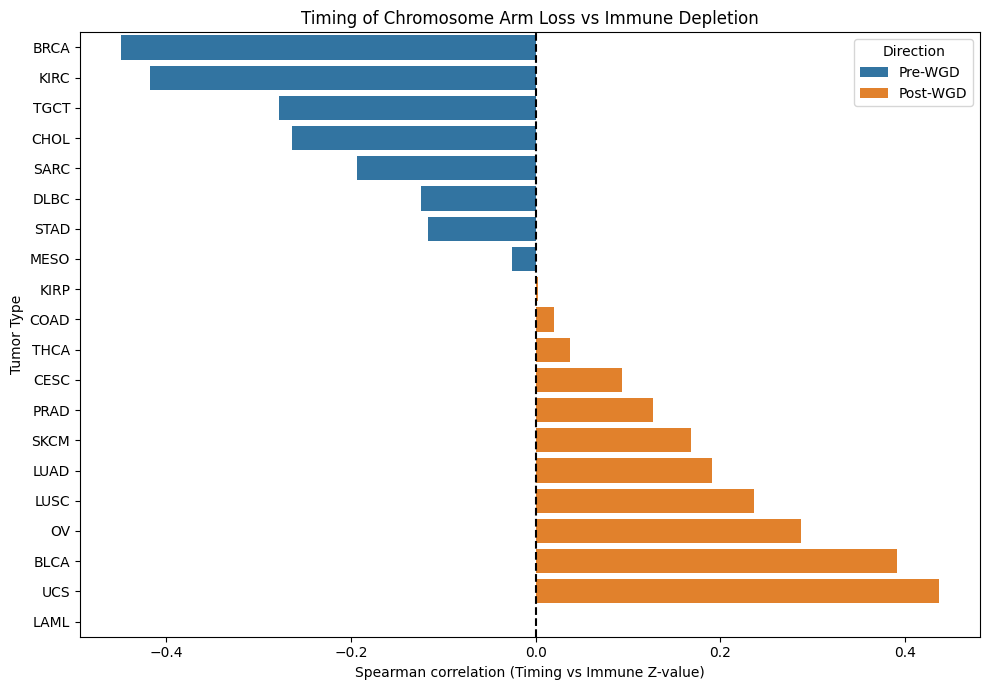

In [34]:
# === Load Z-values (only for Loss events) ===
regression_folder = "/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/TCGA_Deconvolutions_CNV_IS/Arm/Outputs"
files = glob(os.path.join(regression_folder, "*_ArmCNV_binary0.2_regression.csv"))

zval_dict = {}
for f in files:
    tumor_code = os.path.basename(f).split("_")[0]
    df = pd.read_csv(f)
    if 'Event' in df.columns and 'Z_val' in df.columns and 'Arm' in df.columns:
        df_loss = df[df["Event"] == "Loss"]
        zvals = df_loss.set_index("Arm")["Z_val"]
        zval_dict[tumor_code] = zvals

# === Match arms between Z-values and timing ===
results = []
for tumor_code, zvals in zval_dict.items():
    if tumor_code not in timing.index:
        continue
    tvals = timing.loc[tumor_code]
    common_arms = zvals.index.intersection(tvals.index)
    if len(common_arms) < 5:
        continue
    corr, pval = spearmanr(tvals[common_arms], zvals[common_arms])
    direction = "Post-WGD" if corr > 0 else "Pre-WGD"
    results.append({
        "Tumor": tumor_code,
        "Spearman_r": corr,
        "P_value": pval,
        "Direction": direction,
        "N_shared_arms": len(common_arms)
    })

# === Convert to DataFrame and plot ===
result_df = pd.DataFrame(results)
result_df = result_df.sort_values("Spearman_r")

plt.figure(figsize=(10, 7))
sns.barplot(data=result_df, y="Tumor", x="Spearman_r", hue="Direction", dodge=False)
plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Spearman correlation (Timing vs Immune Z-value)")
plt.ylabel("Tumor Type")
plt.title("Timing of Chromosome Arm Loss vs Immune Depletion")
plt.tight_layout()
plt.show()

/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_53245/3612377116.py:70: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(tvals[common_arms], zvals[common_arms])


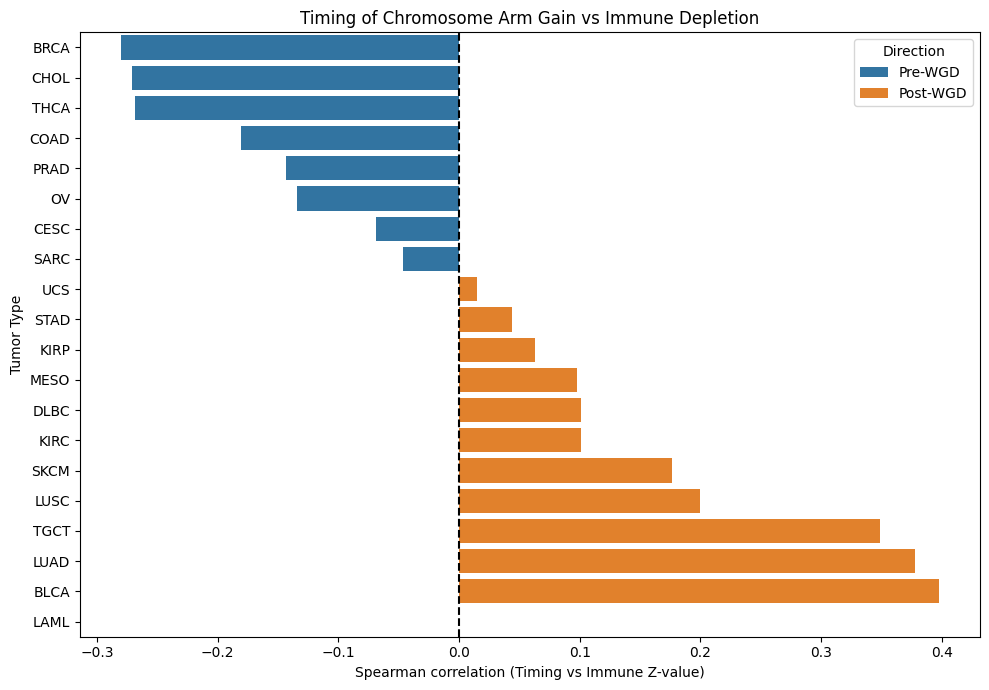

In [35]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from scipy.stats import spearmanr

# === Load pre- and post-WGD gain data ===
pre = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/timing_cancer_events/chr_gains_timing_PeterVanLoo/Pre-WGD gain proportions.csv", index_col=0)
post = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/timing_cancer_events/chr_gains_timing_PeterVanLoo/Post-WGD gain proportions.csv", index_col=0)
timing = post - pre  # higher = later gain events (post-WGD bias)

# === Map full tumor names to TCGA codes ===
tumor_map = {
    "Acute myeloid leukemia": "LAML",
    "Adrenal gland cancer": "ACC",
    "Bladder urothelial carcinoma": "BLCA",
    "Breast carcinoma": "BRCA",
    "Cervical carcinoma": "CESC",
    "Colorectal carcinoma": "COAD",
    "Esophageal carcinoma": "ESCA",
    "Hepatocellular carcinoma": "LIHC",
    "Kidney renal clear cell carcinoma": "KIRC",
    "Kidney renal papillary cell carcinoma": "KIRP",
    "Lung adenocarcinoma": "LUAD",
    "Lung squamous cell carcinoma": "LUSC",
    "Ovarian serous adenocarcinoma": "OV",
    "Pancreas carcinoma": "PAAD",
    "Prostate carcinoma": "PRAD",
    "Skin melanoma": "SKCM",
    "Stomach carcinoma": "STAD",
    "Testis cancer": "TGCT",
    "Thyroid carcinoma": "THCA",
    "Uterus carcinoma": "UCEC",
    "Brain glioma": "LGG",
    "Sarcoma various": "SARC",
    "Mesothelioma": "MESO",
    "Cholangiocarcinoma": "CHOL",
    "Uterus carcinoma, other": "UCS",
    "Vulva and vagina cancer": "VVC",
    "Small cell lung cancer": "SCLC",
    "Upper respiratory tract carcinoma": "URTC",
    "Diffuse large B-cell lymphoma": "DLBC"
}
timing.index = timing.index.to_series().replace(tumor_map)

# === Load immune Z-values for gain events ===
regression_folder = "/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/TCGA_Deconvolutions_CNV_IS/Arm/Outputs"
files = glob(os.path.join(regression_folder, "*_ArmCNV_binary0.2_regression.csv"))

zval_dict = {}
for f in files:
    tumor_code = os.path.basename(f).split("_")[0]
    df = pd.read_csv(f)
    if 'Event' in df.columns and 'Z_val' in df.columns and 'Arm' in df.columns:
        df_gain = df[df["Event"] == "Gain"]
        zvals = df_gain.set_index("Arm")["Z_val"]
        zval_dict[tumor_code] = zvals

# === Correlate gain timing vs immune Z ===
results = []
for tumor_code, zvals in zval_dict.items():
    if tumor_code not in timing.index:
        continue
    tvals = timing.loc[tumor_code]
    common_arms = zvals.index.intersection(tvals.index)
    if len(common_arms) < 5:
        continue
    corr, pval = spearmanr(tvals[common_arms], zvals[common_arms])
    direction = "Post-WGD" if corr > 0 else "Pre-WGD"
    results.append({
        "Tumor": tumor_code,
        "Spearman_r": corr,
        "P_value": pval,
        "Direction": direction,
        "N_shared_arms": len(common_arms)
    })

# === Output & Plot ===
result_df = pd.DataFrame(results)
result_df = result_df.sort_values("Spearman_r")

plt.figure(figsize=(10, 7))
sns.barplot(data=result_df, y="Tumor", x="Spearman_r", hue="Direction", dodge=False)
plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Spearman correlation (Timing vs Immune Z-value)")
plt.ylabel("Tumor Type")
plt.title("Timing of Chromosome Arm Gain vs Immune Depletion")
plt.tight_layout()
plt.show()

/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_53245/1638520051.py:65: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(timing_vals[common], zvals[common])


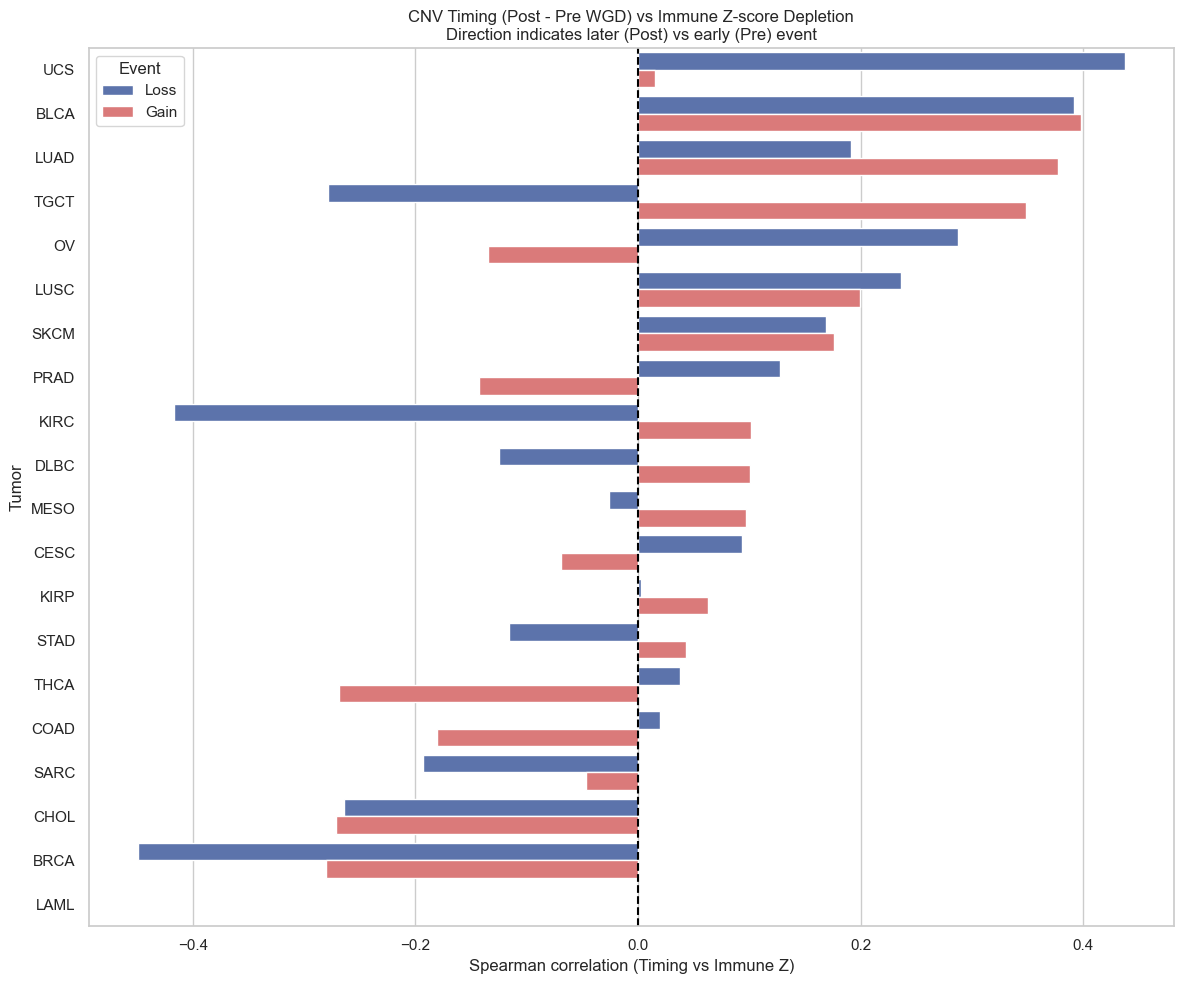

In [48]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from scipy.stats import spearmanr

# === Load timing matrices ===
pre_gain = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/timing_cancer_events/chr_gains_timing_PeterVanLoo/Pre-WGD gain proportions.csv", index_col=0)
post_gain = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/timing_cancer_events/chr_gains_timing_PeterVanLoo/Post-WGD gain proportions.csv", index_col=0)

pre_loss = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/timing_cancer_events/chr_loss_timing_PeterVanLoo/Pre-WGD loss proportions.csv", index_col=0)
post_loss = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/timing_cancer_events/chr_loss_timing_PeterVanLoo/Post-WGD loss proportions.csv", index_col=0)

timing_gain = post_gain - pre_gain
timing_loss = post_loss - pre_loss

# === Tumor name mapping ===
tumor_map = {
    "Acute myeloid leukemia": "LAML", "Adrenal gland cancer": "ACC", "Bladder urothelial carcinoma": "BLCA",
    "Breast carcinoma": "BRCA", "Cervical carcinoma": "CESC", "Colorectal carcinoma": "COAD",
    "Esophageal carcinoma": "ESCA", "Hepatocellular carcinoma": "LIHC", "Kidney renal clear cell carcinoma": "KIRC",
    "Kidney renal papillary cell carcinoma": "KIRP", "Lung adenocarcinoma": "LUAD", "Lung squamous cell carcinoma": "LUSC",
    "Ovarian serous adenocarcinoma": "OV", "Pancreas carcinoma": "PAAD", "Prostate carcinoma": "PRAD",
    "Skin melanoma": "SKCM", "Stomach carcinoma": "STAD", "Testis cancer": "TGCT", "Thyroid carcinoma": "THCA",
    "Uterus carcinoma": "UCEC", "Brain glioma": "LGG", "Sarcoma various": "SARC", "Mesothelioma": "MESO",
    "Cholangiocarcinoma": "CHOL", "Uterus carcinoma, other": "UCS", "Vulva and vagina cancer": "VVC",
    "Small cell lung cancer": "SCLC", "Upper respiratory tract carcinoma": "URTC", "Diffuse large B-cell lymphoma": "DLBC"
}
timing_gain.index = timing_gain.index.to_series().replace(tumor_map)
timing_loss.index = timing_loss.index.to_series().replace(tumor_map)

# === Load regression Z-values ===
regression_folder = "/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/TCGA_Deconvolutions_CNV_IS/Arm/Outputs"
files = glob(os.path.join(regression_folder, "*_ArmCNV_binary0.2_regression.csv"))

results = []

for f in files:
    tumor_code = os.path.basename(f).split("_")[0]
    df = pd.read_csv(f)

    if not {"Z_val", "Arm", "Event"}.issubset(df.columns):
        continue

    for event_type in ["Gain", "Loss"]:
        z_sub = df[df["Event"] == event_type].dropna(subset=["Z_val", "Arm"])
        zvals = z_sub.set_index("Arm")["Z_val"]

        if tumor_code not in timing_gain.index:
            continue

        # Choose correct timing matrix
        timing_matrix = timing_gain if event_type == "Gain" else timing_loss
        if tumor_code not in timing_matrix.index:
            continue

        timing_vals = timing_matrix.loc[tumor_code]

        common = zvals.index.intersection(timing_vals.index)
        if len(common) < 5:
            continue

        corr, pval = spearmanr(timing_vals[common], zvals[common])
        direction = "Post-WGD" if corr > 0 else "Pre-WGD"

        results.append({
            "Tumor": tumor_code,
            "Event": event_type,
            "Spearman_r": corr,
            "P_value": pval,
            "Direction": direction,
            "N_shared_arms": len(common)
        })

# === Output ===
result_df = pd.DataFrame(results)
result_df = result_df.sort_values("Spearman_r", ascending=False)

# === Plot with custom pink/blue
palette = {"Gain": "#EA6A6A", "Loss": "#4F6DB8"}

plt.figure(figsize=(12, 10))
sns.barplot(data=result_df, y="Tumor", x="Spearman_r", hue="Event", dodge=True, palette=palette)
plt.axvline(0, color='black', linestyle='--')
plt.xlabel("Spearman correlation (Timing vs Immune Z)")
plt.title("CNV Timing (Post - Pre WGD) vs Immune Z-score Depletion\nDirection indicates later (Post) vs early (Pre) event")
plt.tight_layout()
plt.savefig("timing_vs_immune_zscore.pdf")
plt.show()

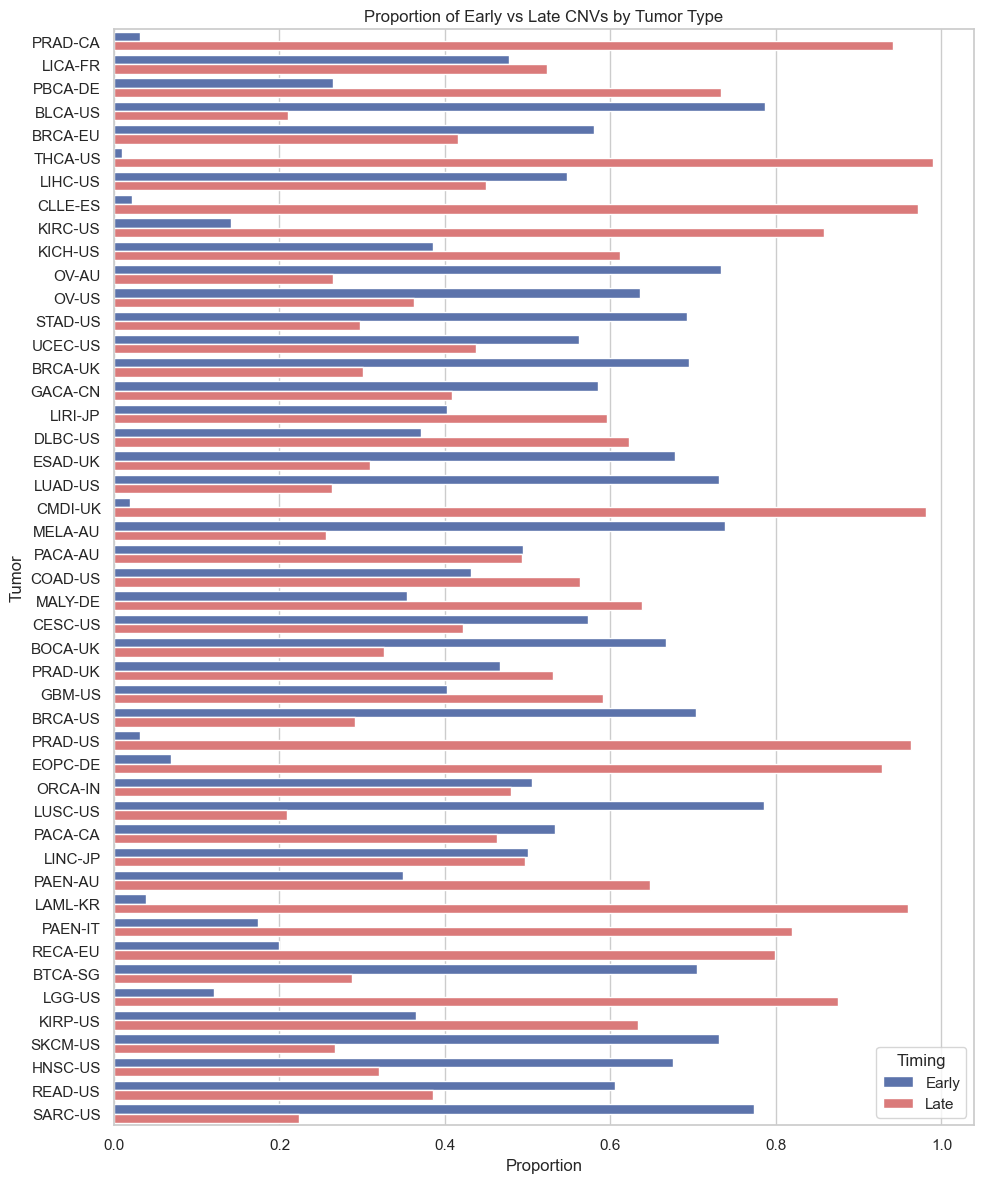

In [39]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

# === Folder with all CNA files ===
cna_dir = "/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/timing_cancer_events/PCAWG_Data/cna"
cna_files = glob(os.path.join(cna_dir, "*_cna.tsv.gz"))

results = []

for f in cna_files:
    tumor_name = os.path.basename(f).replace("_cna.tsv.gz", "")
    try:
        df = pd.read_csv(f, sep="\t", compression="gzip", usecols=["Major"])
    except Exception as e:
        print(f"Skipping {tumor_name}: {e}")
        continue

    df = df.dropna(subset=["Major"])

    df["Timing"] = df["Major"].apply(lambda x: "Early" if x >= 2 else ("Late" if x == 1 else "Unclassified"))
    prop = df["Timing"].value_counts(normalize=True)

    results.append({
        "Tumor": tumor_name,
        "Early": prop.get("Early", 0),
        "Late": prop.get("Late", 0),
    })

# === Convert to DataFrame ===
prop_df = pd.DataFrame(results)

# === Melt to long format for seaborn
plot_df = prop_df.melt(id_vars="Tumor", value_vars=["Early", "Late"], var_name="Timing", value_name="Proportion")

# === Plot stacked bar
plt.figure(figsize=(10, 12))
sns.barplot(data=plot_df, y="Tumor", x="Proportion", hue="Timing", palette={"Early": "#4F6DB8", "Late": "#EA6A6A"})
plt.title("Proportion of Early vs Late CNVs by Tumor Type")
plt.xlabel("Proportion")
plt.ylabel("Tumor")
plt.tight_layout()
plt.show()

100%|██████████| 47/47 [07:31<00:00,  9.60s/it]


<Figure size 1000x1175 with 0 Axes>

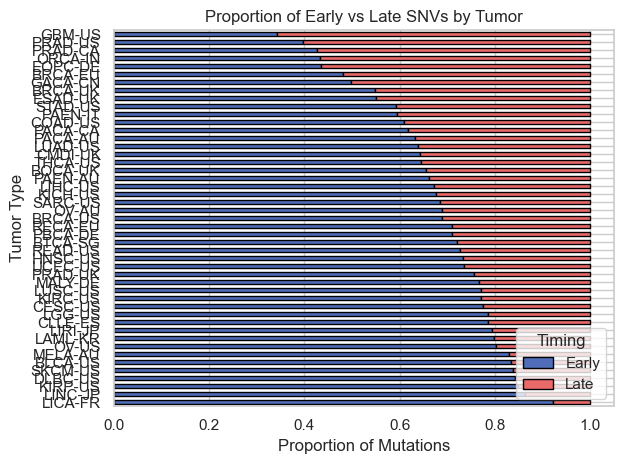

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import glob
from tqdm import tqdm

# === Path to folder with all *_snv.tsv.gz files ===
snv_folder = "/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/timing_cancer_events/PCAWG_Data/snv"   

# === Placeholder purity values (You MUST update these) ===
# Can assign average purity if sample-level purity unavailable
average_purity = 0.7

# === Start analysis ===
summary = []

for file_path in tqdm(glob.glob(os.path.join(snv_folder, "*_snv.tsv.gz"))):
    tumor_code = os.path.basename(file_path).replace("_snv.tsv.gz", "")
    
    try:
        df = pd.read_csv(file_path, sep="\t", low_memory=False)
    except Exception as e:
        print(f"Failed to load {tumor_code}: {e}")
        continue

    # Drop if missing critical columns
    if not {"DP", "NV", "submitted_sample_id"}.issubset(df.columns):
        print(f"Missing critical columns in {tumor_code}")
        continue

    df = df.dropna(subset=["DP", "NV"])
    df["VAF"] = df["NV"] / df["DP"]
    df = df[df["VAF"] <= 1]  # Clean invalid VAFs
    df = df[df["DP"] > 0]    # Remove zero coverage

    # Assign default purity
    df["Purity"] = average_purity

    # Dummy tumor copy number value (replace with segment mapping later)
    df["CN_tumor"] = 3

    # === Estimate multiplicity ===
    df["Multiplicity"] = (df["VAF"] * (df["CN_tumor"] + 2 * (1 - df["Purity"]))) / df["Purity"]

    # === Classify timing ===
    df["Timing"] = df["Multiplicity"].apply(lambda x: "Early" if x > 1 else "Late")
    df["Tumor"] = tumor_code

    # === Proportions
    proportions = df["Timing"].value_counts(normalize=True)
    summary.append({
        "Tumor": tumor_code,
        "Early": proportions.get("Early", 0),
        "Late": proportions.get("Late", 0)
    })

# === Convert to DataFrame for plotting
timing_df = pd.DataFrame(summary)
timing_df = timing_df.sort_values("Late", ascending=True)
timing_df = timing_df.set_index("Tumor")

# === Plot
plt.figure(figsize=(10, len(timing_df) * 0.25))
timing_df[["Early", "Late"]].plot(
    kind="barh",
    stacked=True,
    color=["#4F6DB8", "#EA6A6A"],
    edgecolor="black"
)
plt.xlabel("Proportion of Mutations")
plt.ylabel("Tumor Type")
plt.title("Proportion of Early vs Late SNVs by Tumor")
plt.legend(title="Timing", loc="lower right")
plt.tight_layout()
plt.show()

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from tqdm import tqdm

# === Paths ===
snv_folder = "/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/timing_cancer_events/PCAWG_Data/snv"
cna_folder = "/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/timing_cancer_events/PCAWG_Data/cna"

summary = []

for snv_file in tqdm(glob.glob(os.path.join(snv_folder, "*_snv.tsv*"))):
    tumor_code = os.path.basename(snv_file).replace("_snv.tsv", "").replace("_snv.tsv.gz", "")
    cna_file = os.path.join(cna_folder, f"{tumor_code}_cna.tsv")
    if not os.path.exists(cna_file):
        cna_file = os.path.join(cna_folder, f"{tumor_code}_cna.tsv.gz")
    if not os.path.exists(cna_file):
        print(f"Missing CNA file for {tumor_code}")
        continue

    # Load files
    try:
        snv_df = pd.read_csv(snv_file, sep="\t", low_memory=False)
        cna_df = pd.read_csv(cna_file, sep="\t")
    except Exception as e:
        print(f"Failed to load {tumor_code}: {e}")
        continue

    # Rename for consistency
    if 'sample' in snv_df.columns:
        snv_df = snv_df.rename(columns={"sample": "submitted_sample_id"})
    if 'ID' in cna_df.columns:
        cna_df = cna_df.rename(columns={"ID": "submitted_sample_id"})

    # Check required columns
    if not {"DP", "NV", "submitted_sample_id", "chr", "from"}.issubset(snv_df.columns):
        print(f"Missing columns in SNV for {tumor_code}")
        continue
    if not {"chr", "from", "to", "total_cn", "submitted_sample_id"}.issubset(cna_df.columns):
        print(f"Missing columns in CNA for {tumor_code}")
        continue

    # Calculate VAF
    snv_df = snv_df.dropna(subset=["DP", "NV"])
    snv_df["VAF"] = snv_df["NV"] / snv_df["DP"]
    snv_df = snv_df[(snv_df["VAF"] <= 1) & (snv_df["DP"] > 0)]

    # === CNA matching ===
    snv_df["CN_tumor"] = np.nan
    for sample_id in snv_df["submitted_sample_id"].unique():
        snv_sample_mask = snv_df["submitted_sample_id"] == sample_id
        cna_sample = cna_df[cna_df["submitted_sample_id"] == sample_id]

        for _, seg in cna_sample.iterrows():
            mask = (
                snv_sample_mask &
                (snv_df["chr"] == seg["chr"]) &
                (snv_df["from"] >= seg["from"]) &
                (snv_df["from"] <= seg["to"])
            )
            snv_df.loc[mask, "CN_tumor"] = seg["total_cn"]

    snv_df = snv_df.dropna(subset=["CN_tumor"])

    # Estimate purity per SNV
    snv_df["Purity_est"] = (2 * snv_df["VAF"]) / (snv_df["CN_tumor"] + 2 * snv_df["VAF"] - 2)
    snv_df = snv_df[(snv_df["Purity_est"] > 0) & (snv_df["Purity_est"] < 1)]

    # Median purity per sample
    sample_purity = snv_df.groupby("submitted_sample_id")["Purity_est"].median().to_dict()
    snv_df["Purity"] = snv_df["submitted_sample_id"].map(sample_purity)

    # Multiplicity + Timing
    snv_df["Multiplicity"] = (snv_df["VAF"] * (snv_df["CN_tumor"] + 2 * (1 - snv_df["Purity"]))) / snv_df["Purity"]
    snv_df["Timing"] = snv_df["Multiplicity"].apply(lambda x: "Early" if x > 1 else "Late")
    snv_df["Tumor"] = tumor_code

    # Summary
    proportions = snv_df["Timing"].value_counts(normalize=True)
    summary.append({
        "Tumor": tumor_code,
        "Early": proportions.get("Early", 0),
        "Late": proportions.get("Late", 0)
    })

# === Plot
timing_df = pd.DataFrame(summary)
if "Tumor" not in timing_df.columns or timing_df.empty:
    print("No valid tumors processed. Check SNV/CNA matches.")
else:
    timing_df = timing_df.sort_values("Late", ascending=True).set_index("Tumor")
    plt.figure(figsize=(10, len(timing_df) * 0.25))
    timing_df[["Early", "Late"]].plot(
        kind="barh",
        stacked=True,
        color=["#4F6DB8", "#EA6A6A"],
        edgecolor="black"
    )
    plt.xlabel("Proportion of Mutations")
    plt.ylabel("Tumor Type")
    plt.title("Proportion of Early vs Late SNVs by Tumor\n(using inferred purity from VAF and CN)")
    plt.legend(title="Timing", loc="lower right")
    plt.tight_layout()
    plt.show()

 67%|██████▋   | 33/49 [00:00<00:00, 842.01it/s]

Missing CNA file for ESAD-UK.gz
Missing CNA file for CMDI-UK.gz
Missing CNA file for LUAD-US.gz
Missing CNA file for DLBC-US.gz
Missing CNA file for LIRI-JP.gz
Missing CNA file for GACA-CN.gz
Missing CNA file for BRCA-UK.gz
Missing CNA file for GBM-US.gz
Missing CNA file for PRAD-UK.gz
Missing CNA file for CESC-US.gz
Missing CNA file for MALY-DE.gz
Missing CNA file for BOCA-UK.gz
Missing CNA file for PACA-AU.gz
Missing CNA file for MELA-AU.gz
Missing CNA file for COAD-US.gz
Missing CNA file for BRCA-EU.gz
Missing CNA file for CLLE-ES.gz
Missing CNA file for LIHC-US.gz
Missing CNA file for THCA-US.gz
Missing CNA file for BLCA-US.gz
Missing CNA file for LICA-FR.gz
Missing CNA file for PBCA-DE.gz
Missing CNA file for PRAD-CA.gz
Missing CNA file for STAD-US.gz
Missing CNA file for UCEC-US.gz
Missing CNA file for OV-AU.gz
Missing CNA file for KICH-US.gz
Missing CNA file for KIRC-US.gz
Missing CNA file for OV-US.gz
Missing CNA file for PAEN-IT.gz
Missing CNA file for LINC-JP.gz
Missing CNA f

AttributeError: 'DataFrame' object has no attribute 'unique'

In [41]:
!pip install tqdm

100%|██████████| 47/47 [10:10<00:00, 12.99s/it] 


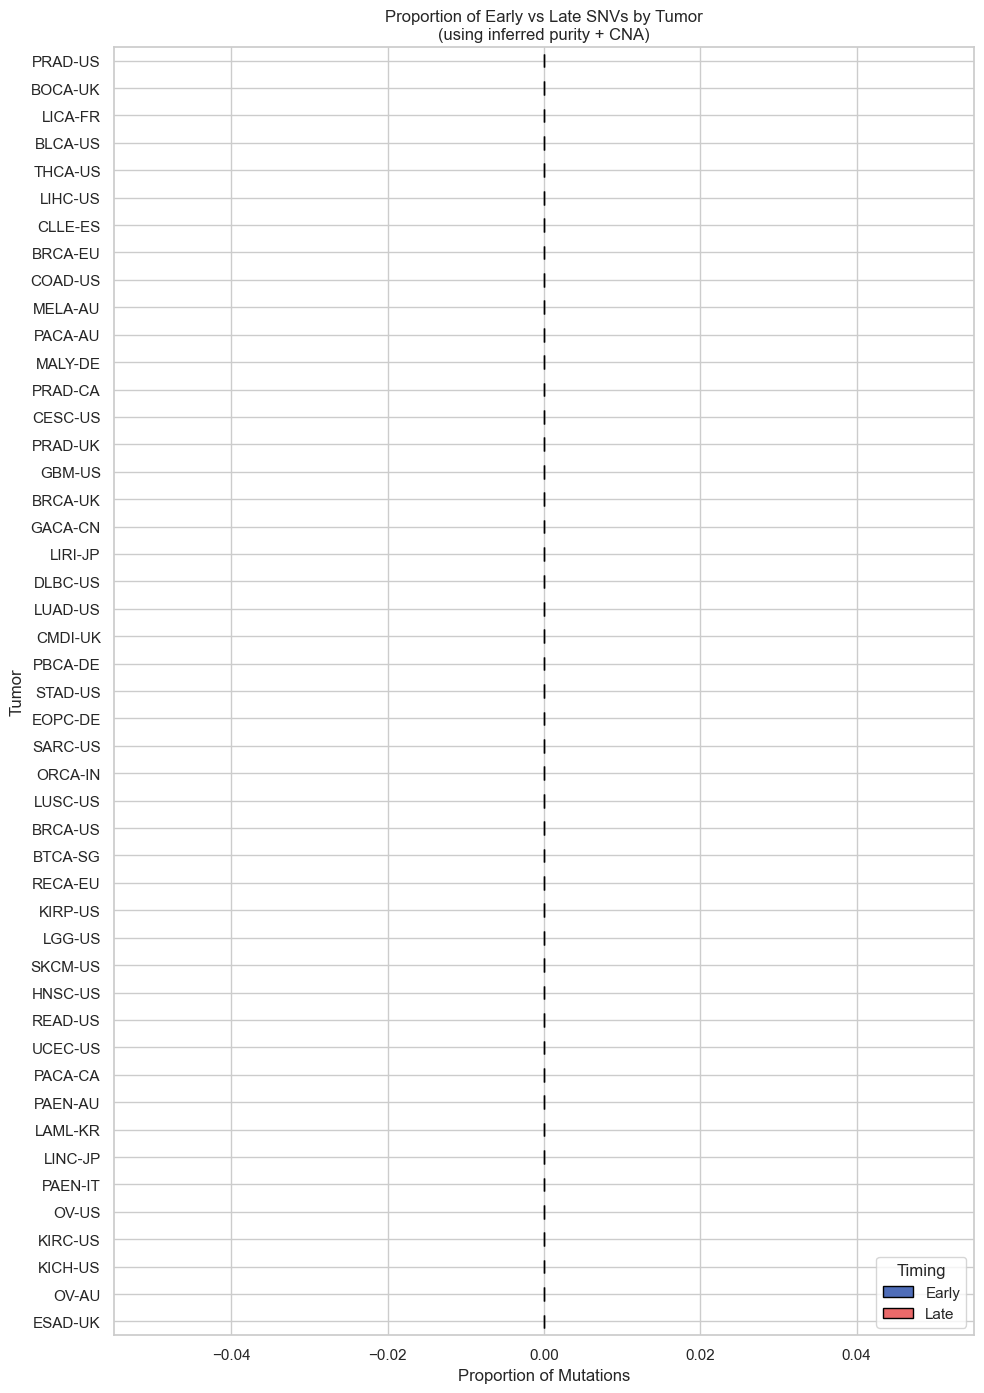

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from tqdm import tqdm

# === Paths ===
snv_folder = "/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/timing_cancer_events/PCAWG_Data/snv"
cna_folder = "/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/timing_cancer_events/PCAWG_Data/cna"

summary = []

# Loop over all SNV files
for snv_file in tqdm(glob.glob(os.path.join(snv_folder, "*_snv.tsv.gz"))):
    tumor_code = os.path.basename(snv_file).replace("_snv.tsv.gz", "")
    cna_file = os.path.join(cna_folder, f"{tumor_code}_cna.tsv.gz")  # always use .tsv.gz

    # Load SNV
    try:
        snv_df = pd.read_csv(snv_file, sep="\t", low_memory=False)
    except Exception as e:
        print(f"❌ Failed to load SNV for {tumor_code}: {e}")
        continue

    # Load CNA
    if not os.path.exists(cna_file):
        print(f"⚠️ Missing CNA file for {tumor_code}")
        continue

    try:
        cna_df = pd.read_csv(cna_file, sep="\t", low_memory=False)
    except Exception as e:
        print(f"❌ Failed to load CNA for {tumor_code}: {e}")
        continue

    # Rename ID column if needed
    if "ID" in cna_df.columns and "submitted_sample_id" not in cna_df.columns:
        cna_df = cna_df.rename(columns={"ID": "submitted_sample_id"})

    # Required columns check
    if not {"DP", "NV", "submitted_sample_id", "chr", "from"}.issubset(snv_df.columns):
        print(f"❌ Missing columns in SNV for {tumor_code}")
        continue
    if not {"chr", "from", "to", "total_cn", "submitted_sample_id"}.issubset(cna_df.columns):
        print(f"❌ Missing columns in CNA for {tumor_code}")
        continue

    # Clean SNVs
    snv_df = snv_df.dropna(subset=["DP", "NV"])
    snv_df = snv_df[(snv_df["DP"] > 0)]
    snv_df["VAF"] = snv_df["NV"] / snv_df["DP"]
    snv_df = snv_df[(snv_df["VAF"] <= 1)]

    # Assign copy number per mutation
    snv_df["CN_tumor"] = np.nan
    for sample_id in snv_df["submitted_sample_id"].unique():
        snv_sub = snv_df["submitted_sample_id"] == sample_id
        cna_sub = cna_df[cna_df["submitted_sample_id"] == sample_id]

        for _, seg in cna_sub.iterrows():
            mask = (
                snv_sub &
                (snv_df["chr"] == seg["chr"]) &
                (snv_df["from"] >= seg["from"]) &
                (snv_df["from"] <= seg["to"])
            )
            snv_df.loc[mask, "CN_tumor"] = seg["total_cn"]

    snv_df = snv_df.dropna(subset=["CN_tumor"])

    # Estimate purity per SNV
    snv_df["Purity_est"] = (2 * snv_df["VAF"]) / (snv_df["CN_tumor"] + 2 * snv_df["VAF"] - 2)
    snv_df = snv_df[(snv_df["Purity_est"] > 0) & (snv_df["Purity_est"] < 1)]

    # Use sample-level purity
    purity_map = snv_df.groupby("submitted_sample_id")["Purity_est"].median().to_dict()
    snv_df["Purity"] = snv_df["submitted_sample_id"].map(purity_map)

    # Multiplicity and timing
    snv_df["Multiplicity"] = (snv_df["VAF"] * (snv_df["CN_tumor"] + 2 * (1 - snv_df["Purity"]))) / snv_df["Purity"]
    snv_df["Timing"] = snv_df["Multiplicity"].apply(lambda x: "Early" if x > 1 else "Late")

    # Count proportions
    props = snv_df["Timing"].value_counts(normalize=True)
    summary.append({
        "Tumor": tumor_code,
        "Early": props.get("Early", 0),
        "Late": props.get("Late", 0)
    })

# === Final plot
summary_df = pd.DataFrame(summary)
if "Tumor" in summary_df.columns:
    summary_df = summary_df.set_index("Tumor").sort_values("Late", ascending=True)
    summary_df[["Early", "Late"]].plot(
        kind="barh", stacked=True,
        color=["#4F6DB8", "#EA6A6A"],
        edgecolor="black", figsize=(10, len(summary_df) * 0.3)
    )
    plt.xlabel("Proportion of Mutations")
    plt.title("Proportion of Early vs Late SNVs by Tumor\n(using inferred purity + CNA)")
    plt.legend(title="Timing", loc="lower right")
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No valid tumors processed for plotting.")